# Congestion Revenue Allocation on the WSCC 9-Bus Network

This notebook builds a unified WSCC 9-bus nodal clearing, then partitions
the network into two balancing authorities (BAs) joined by two tie lines, to
study congestion revenue allocation when one BA's internal
constraint separates prices in the other.

The Western System Coordinating Council (WSCC) 9-bus test represents a simple approximation of the Western System Coordinating Council (WSCC) to an equivalent system with nine buses, three loads, and three generators.

| Section | What you see |
|---|---|
| **0-2. Shared network, shift factors, unified clearing** | DC power flow, nodal LMPs $\lambda_n$, and the per-line congestion-rent decomposition $\sum_l |\mu_l|\bar F_l$ |
| **3. Two balancing authorities** | The BA partition, the two interconnectors, and the congestion-revenue ledger |
| **3A. Tie congested** | Rent collected directly on an interconnector |
| **3B. Internal constraint, external separation** | One BA's *internal* limit separates prices in the *other* BA across the seam |
| **Allocation** | **Method 1** (home BA keeps it) vs **Method 2** (rebate cross-seam separation), side by side |
| **Unified vs independent** | Whether the cross-seam rent survives independent (uncoordinated) operation |

All computation uses [`seams_engine.py`](seams_engine.py); the allocation
methodology is defined inline below so it can be tuned. The cheap generation sits
in **BA-1** (bus 3 \$20 and bus 2 \$35), so BA-1 exports across the seam to
**BA-2**, whose only unit (bus 1 \$50) is dear — that price gap is what the
congestion-revenue allocation then has to divide.

## 0. Setup

In [ ]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

from ieee9_network import build_ieee9_network
import seams_engine, nodal_plot
importlib.reload(seams_engine); importlib.reload(nodal_plot)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

# Clean tables on PDF export: give DataFrames/Series a booktabs LaTeX rendering.
# Jupyter and Colab still show the normal HTML tables; `nbconvert --to pdf` picks
# up this text/latex representation, so tables come out as real ruled tables
# (wide ones scaled to the text width) instead of wrapped monospace.
def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:   # wide -> scale to text width so nothing runs off the page
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

### Generation & load table

The 9-bus system has three generators and three
loads. 

```
        (1)gen $50            (3)gen $20
          |                     |
         [4]---[5]load--------[6]---[7]load
          |                     |
         [9]load---[8]---------/
                    |
                  (2)gen $35
```
Lines (rating MW): `0:1-4(250) 1:4-5(250) 2:5-6(150) 3:3-6(300) 4:6-7(150) 5:7-8(250) 6:8-2(250) 7:8-9(250) 8:9-4(250)`

In [3]:
# Resource stack and loads on the shared network
GEN_FLEET = {
    'gen_slack_0': {'bus': '1', 'cost': 50.0, 'p_nom': 250.0},   # dear unit      (BA-2)
    'gen_0':       {'bus': '2', 'cost': 35.0, 'p_nom': 300.0},   # mid-merit      (BA-1)
    'gen_1':       {'bus': '3', 'cost': 20.0, 'p_nom': 170.0},   # cheapest unit  (BA-1)
}
LOADS = {'5': 90.0, '7': 100.0, '9': 125.0}

# Circlize sector order: clockwise from 12 o'clock, following the network ring
# so the chord diagram reads in the same spatial order as the topology diagram.
RING_ORDER = ['3', '6', '7', '8', '2', '9', '4', '1', '5']

# Orientation, applied to ALL node + circlize plots so they read alike:
#  - node diagram rotated 180deg  -> bus 3 at the bottom, bus 2 NW, bus 9 at top;
#  - circlize centred on bus 9    -> bus 9 across 12 o'clock, bus 3 near the bottom.
ROTATION_DEG = 180
CENTER_BUS = '9'
COORDS = nodal_plot.rotate_coords(nodal_plot.IEEE9_COORDS, ROTATION_DEG)

def build_network(line_ratings=None):
    # Build the 9-bus PyPSA network, applying any line-rating overrides.
    n = build_ieee9_network(periods=1)
    for ln, mw in (line_ratings or {}).items():
        n.lines.loc[ln, 's_nom'] = float(mw)
    return n

def make_engine(name, buses, activated='all'):
    # Assign every fleet gen and load whose bus is in `buses` to this engine.
    buses = {str(b) for b in buses}
    gens = {g: dict(s) for g, s in GEN_FLEET.items() if str(s['bus']) in buses}
    loads = {b: mw for b, mw in LOADS.items() if b in buses}
    return MarketEngine(name=name, gens=gens, loads=loads, activated_lines=activated)

print('fleet:', {g: (s['bus'], s['cost'], s['p_nom']) for g, s in GEN_FLEET.items()})
print('loads:', LOADS)
print('ring order:', RING_ORDER, '| rotation', ROTATION_DEG, 'deg | centre bus', CENTER_BUS)

fleet:

{'gen_slack_0': ('1', 50.0, 250.0), 'gen_0': ('2', 35.0, 300.0), 'gen_1': ('3', 20.0, 170.0)}

loads:

{'5': 90.0, '7': 100.0, '9': 125.0}

ring order:

['3', '6', '7', '8', '2', '9', '4', '1', '5']

| rotation

180

deg | centre bus

9

## 1. Shared network & shift factors

> *A net injection of $p$ MW at bus $n$ produces an incremental flow of
> $SF_{n,m}\,p$ on constraint $m$.*

Each engine's flow $F^M_m=\sum_n SF_{n,m}\,p^{\text{inj},M}_n$
and the LMP congestion term $\sum_m SF_{n,m}\mu_m$ is built.

In [4]:
pt = compute_ptdf(build_network(), slack_bus='1')
SF = pd.DataFrame(pt.ptdf,
                  index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)],
                  columns=[f'bus {b}' for b in pt.buses]).round(3)
print('Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)')
print(SF)


# Canonical per-bus colours: assigned ONCE from the full fleet (which buses host
# gen/load), so every figure -- unified, scenario, or independent per-BA -- uses
# the SAME colour for a given bus. A subset clearing (e.g. one BA alone) no longer
# restarts the palette and reshuffles colours.
_sup_full = {}
for _g, _s in GEN_FLEET.items():
    _sup_full.setdefault(_s['bus'], []).append(_s)
BUS_COLORS = assign_bus_colors(pt.buses, _sup_full, LOADS)


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)

              bus 1  bus 2  bus 3  bus 4  bus 5  bus 6  bus 7  bus 8  bus 9
line_0 (1-4)    0.0 -1.000 -1.000   -1.0 -1.000 -1.000 -1.000 -1.000 -1.000
line_1 (4-5)    0.0 -0.361 -0.615   -0.0 -0.865 -0.615 -0.467 -0.361 -0.125
line_2 (5-6)    0.0 -0.361 -0.615   -0.0  0.135 -0.615 -0.467 -0.361 -0.125
line_3 (3-6)    0.0  0.000  1.000   -0.0  0.000  0.000 -0.000  0.000  0.000
line_4 (6-7)    0.0 -0.361  0.385    0.0  0.135  0.385 -0.467 -0.361 -0.125
line_5 (7-8)    0.0 -0.361  0.385   -0.0  0.135  0.385  0.533 -0.361 -0.125
line_6 (8-2)    0.0 -1.000  0.000    0.0  0.000  0.000  0.000  0.000  0.000
line_7 (8-9)    0.0  0.639  0.385    0.0  0.135  0.385  0.533  0.639 -0.125
line_8 (9-4)    0.0  0.639  0.385    0.0  0.135  0.385  0.533  0.639  0.875

### Line admittance map

The WSCC 9-bus assigns a distinct reactance $x_m$ to every line. For DC flow the
power a line carries per unit of angle difference across its **susceptance**
$b_m = 1/x_m$. The cell below draws each line with a width
proportional to $b_m$ (wider = lower $x$ = more admittance), giving a physical
picture of where power prefers to flow before any dispatch is chosen. 

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


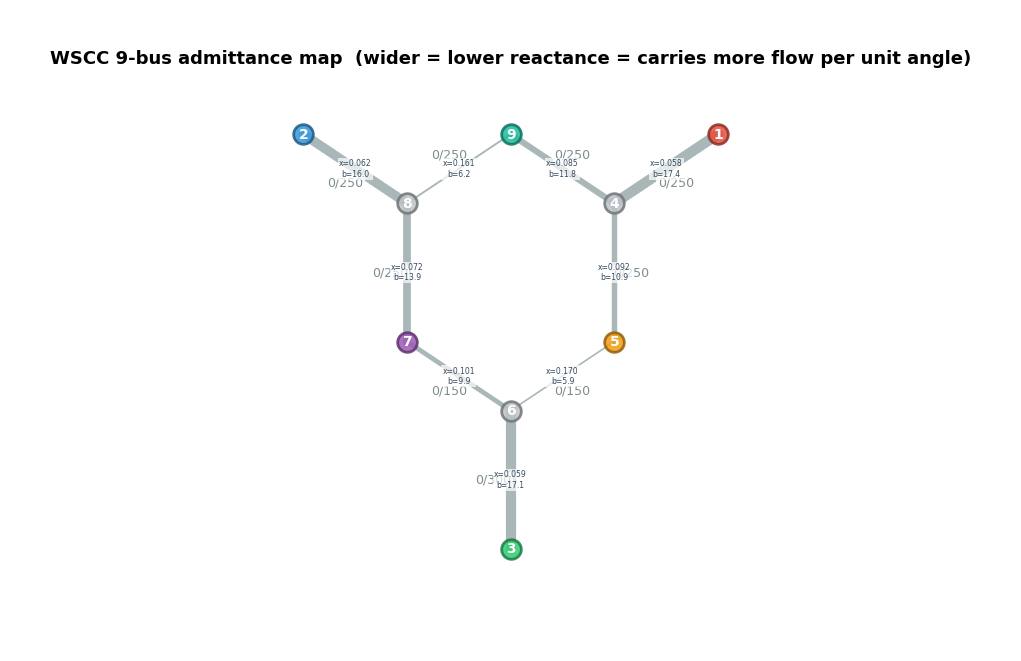

,x (reactance),b = 1/x,draw width
line_0 (1-4),0.0576,17.36,7.50
line_3 (3-6),0.0586,17.06,7.34
line_6 (8-2),0.0625,16.00,6.75
line_5 (7-8),0.0720,13.89,5.59
line_8 (9-4),0.0850,11.76,4.43
line_1 (4-5),0.0920,10.87,3.94
line_4 (6-7),0.1008,9.92,3.42
line_7 (8-9),0.1610,6.21,1.38
line_2 (5-6),0.1700,5.88,1.20


In [5]:
pt = compute_ptdf(build_network(), slack_bus='1')
widths = susceptance_widths(pt, wmin=1.2, wmax=7.5)   # {line: linewidth} from b = 1/x

# Colour the nodes with the SAME per-bus palette used throughout the notebook:
# gen/load buses take their palette colour, pure transit buses stay grey. The
# membership comes from the fleet (not the dispatch), so these node colours match
# the dispatched figures exactly -- this is purely a susceptance map, no flows.
node_colors = BUS_COLORS   # canonical per-bus palette (defined with pt above)

# Pure susceptance map: no dispatch annotations, no flows -- width encodes
# admittance only, nodes carry the standard palette colour.
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=node_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines},   # 0 flow -> no arrows, grey lines
    line_widths=widths,
    title='WSCC 9-bus admittance map  (wider = lower reactance = carries more flow per unit angle)',
)
# annotate each line with its x and b
for l, (b0, b1) in zip(pt.lines, pt.line_buses):
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    b = pt.susceptance[pt.line_idx[l]]
    ax.text(xm, ym, f'x={1/b:.3f}\nb={b:.1f}', fontsize=5.5, ha='center', va='center',
            color='#34495E', bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.8), zorder=6)
plt.show()

pd.DataFrame({
    'x (reactance)': [round(1 / pt.susceptance[pt.line_idx[l]], 4) for l in pt.lines],
    'b = 1/x': [round(pt.susceptance[pt.line_idx[l]], 2) for l in pt.lines],
    'draw width': [round(widths[l], 2) for l in pt.lines],
}, index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)]).sort_values('b = 1/x', ascending=False)

## 2. One engine — the unified clearing

### The dispatch each engine solves, its Lagrangian, and the bus prices

`solve_engine_dispatch` clears **one engine's** DC-OPF on the shared network: a
bid-based security-constrained economic dispatch (SCED) reduced to a **single
period with energy-cost bids only** (no unit commitment) and a **single
system-wide energy balance**. An engine $M$ brings its resources $\mathcal R^M$
(cost $c_i$, cap $\bar g_i$ at bus $\mathrm{bus}(i)$), its served load $d_n$, an
activated line set $\mathcal M^M_{\mathrm{act}}$, and any **exogenous** cross-seam
schedule $\mathrm{exo}_n$ (zero for a stand-alone clear).

**Objective — minimise the engine's own dispatch cost.**

$$\min_{0\le g_i\le \bar g_i}\ \ C^M=\sum_{i\in\mathcal R^M} c_i\,g_i. \qquad\qquad(1)$$

*In words.* Stack up the engine's own generators cheapest-first to cover its obligation
(no-load, start-up and shut-down terms drop out in this single-period, energy-only cut).

**Energy balance — its dual is the energy price $\lambda^M$.**

$$\sum_{i\in\mathcal R^M} g_i=\sum_n d_n-\sum_n \mathrm{exo}_n. \qquad\qquad(2)\quad[\lambda^M]$$

*In words.* The engine's generation serves its own load net of any scheduled interchange:
$\mathrm{exo}_n>0$ is power injected into the footprint (an import), $\mathrm{exo}_n<0$ a
withdrawal (an export). $\lambda^M$ is the single system-wide energy price (`res.energy_price`).

**Flow and activated limits — duals $\mu^M_m$.**

$$F^M_m=\sum_n SF_{n,m}\,p^{\mathrm{inj},M}_n,\qquad
  -\bar F_m\le F^M_m\le \bar F_m\ \ [\mu^M_m]\ \ (m\in\mathcal M^M_{\mathrm{act}}),\qquad
  p^{\mathrm{inj},M}_n=\!\!\!\sum_{i\in\mathcal R^M:\,\mathrm{bus}(i)=n}\!\!\!g_i-d_n+\mathrm{exo}_n. \qquad(3)$$

*In words.* The engine's flow on a line is the shift-factor-weighted sum of **its own** net
injections, held within the rating **only on the lines it activates**. A line outside
$\mathcal M^M_{\mathrm{act}}$ has its limit relaxed and stays silent (`activated_lines`).

**The Lagrangian.**

$$\mathcal L^M(g,\lambda^M,\mu^M,\underline\mu^M,\overline\mu^M)=\sum_i c_i\,g_i-\lambda^M\!\Big(\sum_i g_i-\sum_n d_n+\sum_n\mathrm{exo}_n\Big)-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!\mu^M_m\,F^M_m+\sum_i\overline\mu^M_i\,(g_i-\bar g_i)-\sum_i\underline\mu^M_i\,g_i. \qquad(4)$$

*In words.* Cost, minus the energy-balance multiplier times the imbalance, minus each activated
line's (signed) congestion multiplier times the flow on it, plus one multiplier per generator
capacity limit: $\overline\mu^M_i\ge 0$ on the upper limit $g_i\le\bar g_i$ and
$\underline\mu^M_i\ge 0$ on the lower limit $g_i\ge 0$. $\lambda^M$ and the $\mu^M_m$ are exactly
`res.energy_price` and `res.line_dual`.

**Complementary slackness.** Each capacity multiplier is non-zero only when its own limit binds:

$$\overline\mu^M_i\,(g_i-\bar g_i)=0,\qquad \underline\mu^M_i\,g_i=0,\qquad \overline\mu^M_i,\underline\mu^M_i\ge 0.$$

A fully-loaded unit ($g_i=\bar g_i$) may carry $\overline\mu^M_i>0$, an idle unit ($g_i=0$) may
carry $\underline\mu^M_i>0$, and a **marginal** unit ($0<g_i<\bar g_i$) has both equal to zero.

**Stationarity — where the price comes from.** At the optimum the Lagrangian is stationary in
each dispatch variable. For a generator $i$ at bus $n=\mathrm{bus}(i)$, using $\partial F^M_m/\partial g_i=SF_{n,m}$:

$$\frac{\partial \mathcal L^M}{\partial g_i}
  = c_i-\lambda^M-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^M_m\;+\;\overline\mu^M_i-\underline\mu^M_i\;=\;0 .$$

For a **marginal** unit the two bound multipliers vanish by complementary slackness, so the
$\overline\mu^M_i-\underline\mu^M_i$ term drops and we are left with
$c_i=\lambda^M+\sum_{m}SF_{n,m}\,\mu^M_m$.

**Nodal LMP — the price at every bus.**

$$\lambda^M_n=\lambda^M+\sum_{m\in\mathcal M^M_{\mathrm{act}}}SF_{n,m}\,\mu^M_m. \qquad\qquad(5)$$

*In words.* A bus's price is the system energy price plus, for every binding activated line, that
line's shadow price scaled by the bus's shift factor onto it. With nothing binding, every bus
collapses to the one price $\lambda^M$. **Section 2 runs the unified counterfactual**: a single
engine over **all** buses with $\mathrm{exo}=0$ and every limit enforced — the single-price
benchmark the rest of the notebook builds on.

### Congestion rent

Unified clearing is the single engine over **all** buses ($\mathrm{exo}=0$, every
line activated), so we drop the engine superscript: write $\lambda_n\equiv\lambda^M_n$,
$\mu_l\equiv\mu^M_l$, and $\mathcal M_{\mathrm{act}}$ for the activated set. Value each binding
line's limit at its shadow price which is equivalent to the net the bus-level payments:

$$R=\sum_{l\in\mathcal M_{\mathrm{act}}}|\mu_l|\,|F_l|
   =\underbrace{\sum_n\lambda_n d_n}_{\text{paid by load}}
   -\underbrace{\sum_n\lambda_n g_n}_{\text{paid to generation}}. \qquad (6)$$

*In words.* The congestion rent (merchandising surplus) is the shadow price of each binding
line times the power on it — and it equals exactly what load pays minus what generation is
paid, because the energy components net to zero (total generation $=$ total load). **No
binding line $\Rightarrow$ no price separation $\Rightarrow R=0$.** 

**Edit below:** generator costs, load levels, and line ratings. Limiting a line rating may
create congestion and price separation on the constrained
path.

In [6]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_4': 40.0}   # adjust line_4 (6-7, internal to BA-1) below its ~63 MW natural flow
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 0.0, 'gen_0': 176.1, 'gen_1': 138.9}

energy price :

27.74

$/MWh

binding lines:

{'line_4': -20.1}

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,27.74,35.0,20.0,27.74,25.02,20.0,37.13,35.0,30.25


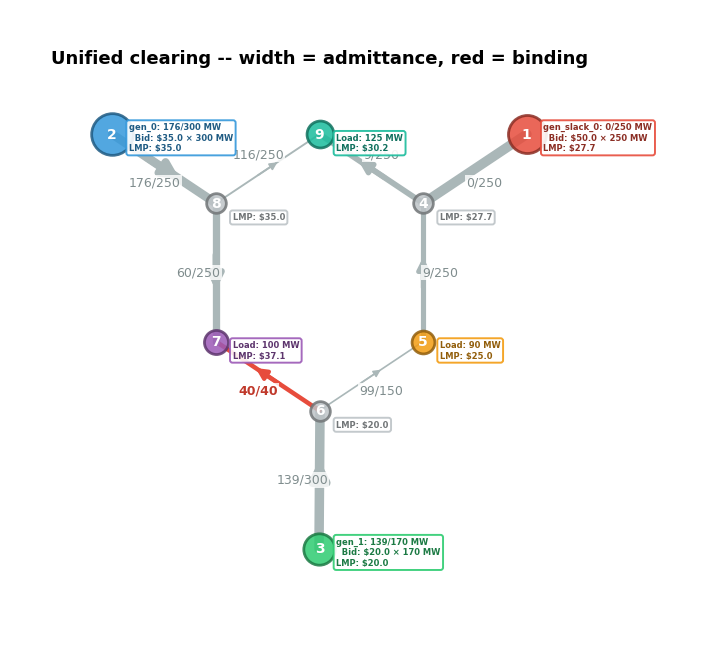

In [7]:
# Topology with DC power flow. Line WIDTH = susceptance (b=1/x); line COLOUR =
# congestion. A line is red only when its shadow price is non-zero (a genuine
# binding transmission limit) -- NOT merely when flow hits rating, which can
# happen because the generator behind a radial line is maxed out.
sup, dem = to_supply_demand(unified, res)
colors = dict(BUS_COLORS)   # canonical colours; a subset clearing no longer reshuffles them
flows = {l: res.flow_own[l] for l in pt.lines}
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=colors, bus_lmps=res.lmp, line_flows=flows,
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines, bus_coords=COORDS,
    title='Unified clearing -- width = admittance, red = binding',
)
plt.show()

### Nodal merit-order + dispatch view, and the congestion shadow price

The circlize / chord view, built here from the unified DC-OPF. Each sector is a bus. The bar's height for a generator is that unit's marginal cost (its bid) -- solid
where dispatched, faded where it is available capacity. A **dashed line is drawn across each
bus at its cleared LMP**; the gap between a dispatched bar's top and that line is the unit's
**inframarginal rent** (LMP - marginal cost), while a bar rising *above* the line is out of
merit at this price and stays undispatched. The bar's height for a demand bus is drawn at LMP height, and the
**chords** are PTDF-traced generator→load deliveries. Below the figure we print the
congestion shadow price $\mu_m$ on each binding line — the dual of the binding-line
limit, and the exact quantity that splits the LMPs through $\sum_m SF_{n,m}\,\mu_m$.

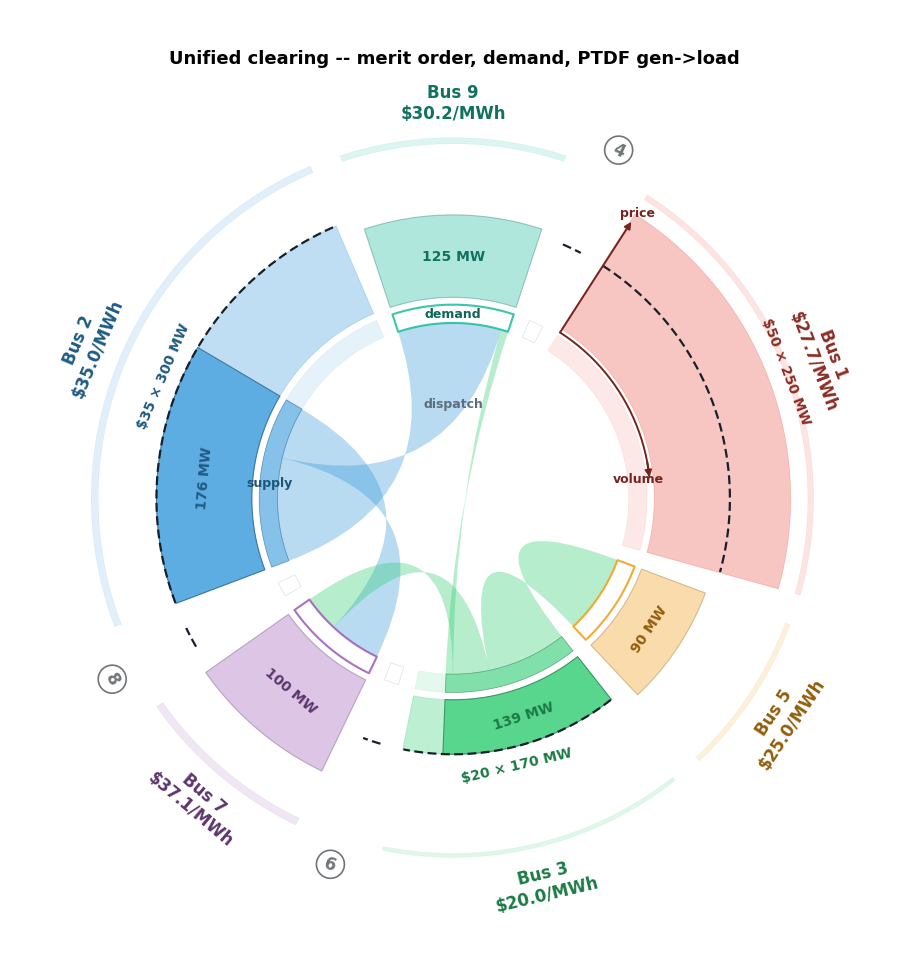

Binding transmission constraints -- congestion shadow price |mu_m|:

  line_4 (6-7): |mu| = $20.10/MWh   (flow +40 MW at the 40 MW limit)


Settlement by node  (payments to generation vs payments by load):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,27.74,0.0,0.0,0.0,0.0
2,35.0,176.1,6162.4,0.0,0.0
3,20.0,138.9,2778.6,0.0,0.0
4,27.74,0.0,0.0,0.0,0.0
5,25.02,0.0,0.0,90.0,2251.8
6,20.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
8,35.0,0.0,0.0,0.0,0.0
9,30.25,0.0,0.0,125.0,3780.8


Congestion rent  =  paid by load  -  paid to gen  =  9,745.2  -  8,941.0  =  $804.2/h

...

(equal by the LMP decomposition: the energy component nets to zero because total gen = total load,
 so only the congestion term survives, and it equals mu x flow on each binding line.)


Marginal value of line capacity  (shadow price x flow, per line):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,-0.0,250.0,False,0.0,0.0
line_1,4,5,-8.9,250.0,False,0.0,0.0
line_2,5,6,-98.9,150.0,False,0.0,0.0
line_3,3,6,138.9,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-176.1,250.0,False,0.0,0.0
line_7,8,9,116.1,250.0,False,0.0,0.0
line_8,9,4,-8.9,250.0,False,0.0,0.0


The |mu| column is the value of relaxing each line by 1 MW; only binding lines carry a positive value.
The rent column decomposes the congestion rent above by line and totals $804.1/h.


wrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  C:\Users\docke\Projects\ASSUME\assume\testbed

In [8]:
# Circlize / chord view of the unified clearing (reuses sup, dem, colors, res from above).
flow_list = nodal_plot.compute_ptdf_flows(net, sup, dem)   # PTDF-traced gen->load chords

fig = plot_nodal_circlize(
    sup, dem, pt.buses,
    flows=flow_list,
    clearing_price=res.energy_price,
    bus_lmps=res.lmp,
    bus_colors=colors,
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost (gap = inframarginal rent)
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    sector_order=RING_ORDER,   # clockwise from 12 o'clock, following the network ring
    center_bus=CENTER_BUS,     # bus 9 centred at 12 o'clock (matches the rotated node diagram)
    figsize=(8.5, 9.0),        # fills the width of an 8.5x11 page (extra height -> title headroom)
    label_fontsize=12,         # outer sector labels (Bus N / LMP)
    track_fontsize=10,         # in-track bid / dispatch / load-MW labels, >= 10 pt
    show_legend=False,         # per-bus gen/load/LMP already on the ring + in-track; legend was sub-10 pt and duplicative
    title='Unified clearing -- merit order, demand, PTDF gen->load',
)
plt.show()

# Shadow price of the binding line constraint(s): the congestion dual mu_m.
binding = {l: mu for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
if binding:
    print('Binding transmission constraints -- congestion shadow price |mu_m|:')
    for l, mu in sorted(binding.items(), key=lambda kv: -abs(kv[1])):
        i = pt.line_idx[l]; a, b = pt.line_buses[i]
        print(f'  {l} ({a}-{b}): |mu| = ${abs(mu):.2f}/MWh   '
              f'(flow {res.flow_own[l]:+.0f} MW at the {pt.s_nom[i]:.0f} MW limit)')
else:
    print('No binding line constraints -- every bus collapses to the single energy price.')

# â”€â”€ Settlement accounting: payments by node, subtotals, congestion rent â”€â”€â”€â”€â”€â”€
# Convention: "paid to gen" is cash IN to generators (LMP x dispatch); "paid by
# load" is cash OUT from loads (LMP x demand). The system operator collects the
# difference as congestion rent / merchandising surplus -- and that residual
# equals the shadow-price money  sum_m |mu_m| * F_m  (the price-difference rent).
settle = pd.DataFrame(
    [{'bus': b,
      'LMP ($/MWh)': round(res.lmp[b], 2),
      'gen (MW)': round(res.gen_by_bus.get(b, 0.0), 1),
      'paid to gen ($/h)': round(res.lmp[b] * res.gen_by_bus.get(b, 0.0), 1),
      'load (MW)': round(unified.loads.get(b, 0.0), 1),
      'paid by load ($/h)': round(res.lmp[b] * unified.loads.get(b, 0.0), 1)}
     for b in pt.buses]
).set_index('bus')

gen_rev  = settle['paid to gen ($/h)'].sum()    # subtotal: total to generation
load_pay = settle['paid by load ($/h)'].sum()   # subtotal: total from load
settle.loc['SUBTOTAL'] = ['', settle['gen (MW)'].sum(), gen_rev,
                          settle['load (MW)'].sum(), load_pay]

print('\nSettlement by node  (payments to generation vs payments by load):')
display(settle)

cong_rent = load_pay - gen_rev
mu_money  = sum(abs(mu) * abs(res.flow_own[l]) for l, mu in binding.items())
print(f'Congestion rent  =  paid by load  -  paid to gen  '
      f'=  {load_pay:,.1f}  -  {gen_rev:,.1f}  =  ${cong_rent:,.1f}/h')
print(f'Shadow-price check:  sum_m |mu_m| * F_m over binding lines  =  ${mu_money:,.1f}/h')
print('(equal by the LMP decomposition: the energy component nets to zero because '
      'total gen = total load,\n so only the congestion term survives, and it equals mu x flow on each binding line.)')

# â”€â”€ Marginal value of line capacity: shadow price x flow, per line â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# |mu_m| is the $/MWh fall in system cost from +1 MW of rating on line m (zero
# unless the line binds) -- the marginal value of capacity. |mu_m| x flow is the
# congestion rent that line collects; the column sums to the total rent above.
lines_tbl = pd.DataFrame(
    [{'line': l,
      'from': pt.line_buses[pt.line_idx[l]][0],
      'to': pt.line_buses[pt.line_idx[l]][1],
      'flow (MW)': round(res.flow_own[l], 1),
      'rating (MW)': round(pt.s_nom[pt.line_idx[l]], 0),
      'binding': abs(res.line_dual[l]) > 1e-3,
      '|mu| ($/MWh = value of +1 MW)': round(abs(res.line_dual[l]), 2),
      'rent |mu| x flow ($/h)': round(abs(res.line_dual[l]) * abs(res.flow_own[l]), 1)}
     for l in pt.lines]
).set_index('line')
lines_tbl.loc['TOTAL'] = ['', '', '', '', '', '',
                          round(lines_tbl['rent |mu| x flow ($/h)'].sum(), 1)]

print('\nMarginal value of line capacity  (shadow price x flow, per line):')
display(lines_tbl)
print('The |mu| column is the value of relaxing each line by 1 MW; only binding '
      'lines carry a positive value.\nThe rent column decomposes the congestion '
      f'rent above by line and totals ${lines_tbl.loc["TOTAL", "rent |mu| x flow ($/h)"]:,.1f}/h.')

# â”€â”€ Export both tables to CSV (overwritten every run) for the Word write-up â”€â”€
settle.to_csv('seams_settlement_by_node.csv')
lines_tbl.to_csv('seams_line_capacity_value.csv')
print(f'\nwrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  {os.getcwd()}')

### Composite figure 

The network diagram and the circlize/chord diagram laid out side by side,
sized so the fonts stay clean at half-page width:

- node numbers sit in small chips **beside** each bubble (the coloured marker stays
  uncluttered); only the **LMP** is printed at each bus — the gen/bid/load detail
  lives in the chord panel, so nothing is duplicated;
- on each circlize sector the **bid** sits *outside / on top of* the gen bar and the
  **dispatched MW** sits *inside* it (mirroring the load bar, which prints its MW
  in-track); in-track labels are placed by bar height so they stay inside the bar;
- saved as a PNG and a vector PDF, overwritten each run.

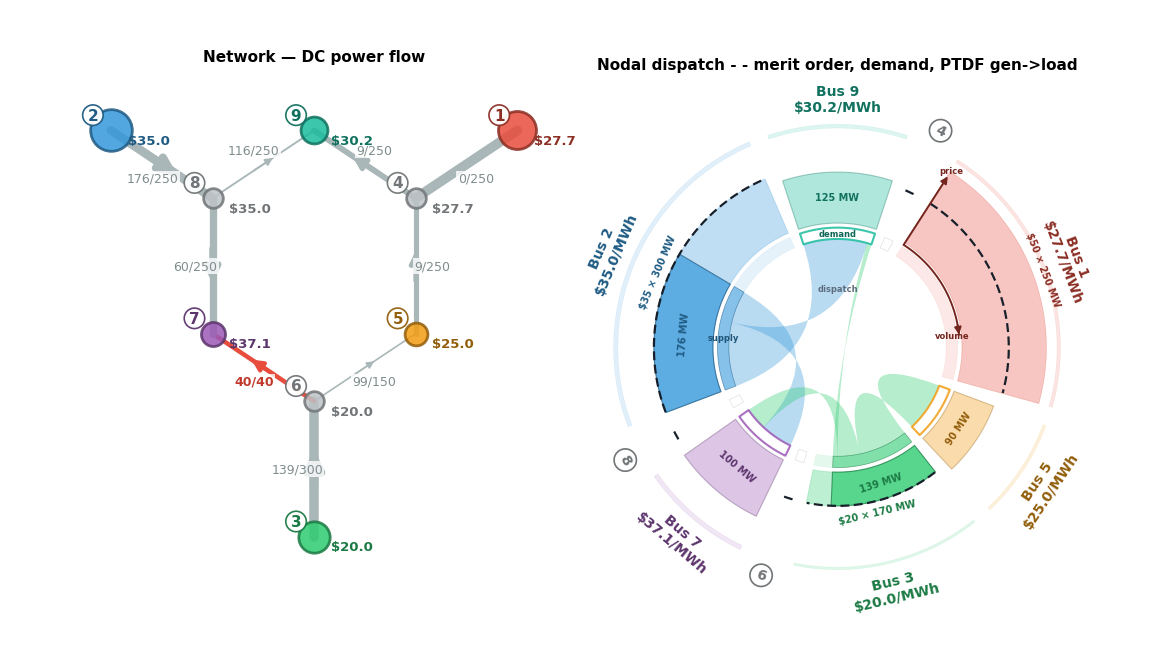

wrote seams_combined_figure.png (600 dpi) and seams_combined_figure.pdf to C:\Users\docke\Projects\ASSUME\assume\testbed

In [9]:
from nodal_plot import plot_combined_letter

binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp,
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, dem),
    clearing_price=res.energy_price,
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,   # rotated node diagram + bus 9 at 12 o'clock
    title_right='Nodal dispatch - - merit order, demand, PTDF gen->load',
)
fig.savefig('seams_combined_figure.png', dpi=600, bbox_inches='tight')
fig.savefig('seams_combined_figure.pdf', bbox_inches='tight')   # vector, for Word
plt.show()
print(f'wrote seams_combined_figure.png (600 dpi) and seams_combined_figure.pdf to {os.getcwd()}')

**Read it:** with `line_4` (6–7) limited to 40 MW, the binding internal limit
splits the LMPs — the bus-7 load behind the constraint prices up to ~\$37 while the
cheap bus-3 pocket (\$20) stays low. The congestion term is exactly
$\sum_m SF_{n,m}\,\mu_m$; set `LINE_RATINGS = {}` and re-run to collapse every bus
back to a single energy price.

## 3. Two balancing authorities on the shared network

The same 9-bus nodal network, now configured as **two balancing authorities** that
co-optimise a single dispatch but settle separately. The partition is an
*accounting overlay* on the unified clearing of Section 2 — the physics and the
LMPs are unchanged; the new question is **where the congestion revenue lands**.

- **BA-1** = buses {2, 8, 7, 6, 3} — the **cheap fleet** (gen_1 \$20 @ bus 3,
  gen_0 \$35 @ bus 2) and load at bus 7.
- **BA-2** = buses {1, 9, 4, 5} — only the **dear** unit (gen_slack_0 \$50 @ bus 1)
  and loads at buses 5 and 9.

This partition leaves **exactly two tie lines** (interconnectors) between the
BAs: `line_2` (5-6) and `line_7` (8-9). Every other line is internal to one BA.
BA-1 (cheap) tends to export across the seam to BA-2 (dear).

*Reading the figures below.* Lines are **coloured by the BA that manages them** (BA-1 purple, BA-2 blue); the two tie lines stay **grey** since no single BA owns them, and any line that turns **bright red** is congested (a binding limit), which overrides its BA colour. On the chord diagram each BA's arc carries a matching **outer band and label**, and a **dashed line on each generator marks its bus LMP** over the marginal-cost fill -- the gap is that unit's inframarginal rent.

In [10]:
# Section 3 config: the two balancing authorities 
BA_DEFS = {
    'BA-1': ['2', '8', '7', '6', '3'],   # the cheap fleet (bus 3 $20, bus 2 $35); load at 7 -> net exporter
    'BA-2': ['1', '9', '4', '5'],         # only the dear bus-1 unit ($50); loads at 5 and 9 -> net importer
}
BA_COLORS = {'BA-1': "#993AFF", 'BA-2': '#2471A3'}

bus_to_ba = {str(b): ba for ba, buses in BA_DEFS.items() for b in buses}
ba_of = lambda b: bus_to_ba[str(b)]
LOADS_ALL = dict(LOADS)   # {'5': 90, '7': 100, '9': 125}

def line_kind(pt, l):
    # ('internal', ba) if both ends share a BA, else ('tie', None)
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    return ('internal', ba_of(b0)) if ba_of(b0) == ba_of(b1) else ('tie', None)

pt = compute_ptdf(build_network(), slack_bus='1')
ties = [l for l in pt.lines if line_kind(pt, l)[0] == 'tie']

print('BA-1 buses:', BA_DEFS['BA-1'])
print('BA-2 buses:', BA_DEFS['BA-2'])
print('tie lines :', [f"{l} ({pt.line_buses[pt.line_idx[l]][0]}-{pt.line_buses[pt.line_idx[l]][1]})" for l in ties])
print('internal BA-1:', [l for l in pt.lines if line_kind(pt, l) == ('internal', 'BA-1')])
print('internal BA-2:', [l for l in pt.lines if line_kind(pt, l) == ('internal', 'BA-2')])

# -- BA line colours + group map (used by the BA map and every Section-3 figure)
def ba_line_colors(pt):
    # Internal lines take their managing BA's colour; ties (cross-BA) stay grey.
    out = {}
    for l in pt.lines:
        kind, ba = line_kind(pt, l)
        out[l] = BA_COLORS[ba] if kind == 'internal' else '#AAB7B8'
    return out

BA_GROUPS = {b: ba_of(b) for b in pt.buses}   # {bus: 'BA-1'/'BA-2'} for circlize banding


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


BA-1 buses:

['2', '8', '7', '6', '3']

BA-2 buses:

['1', '9', '4', '5']

...

['line_2 (5-6)', 'line_7 (8-9)']

internal BA-1:

['line_3', 'line_4', 'line_5', 'line_6']

internal BA-2:

['line_0', 'line_1', 'line_8']

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


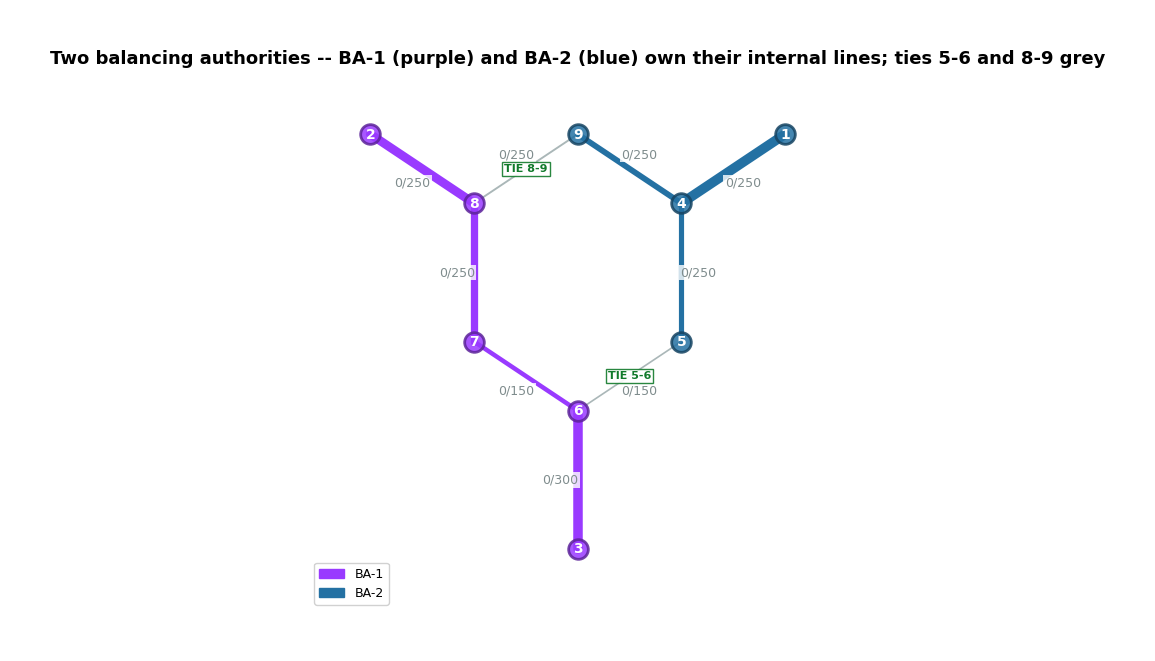

In [11]:
# Map of the two BAs and the interconnectors (buses coloured by BA).
ba_bus_colors = {b: BA_COLORS[ba_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=ba_bus_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=ba_line_colors(pt),   # lines coloured by the BA that manages them; ties grey
    title='Two balancing authorities -- BA-1 (purple) and BA-2 (blue) own their internal lines; ties 5-6 and 8-9 grey',
)
for l in ties:
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    ax.text((x0+x1)/2, (y0+y1)/2, f'TIE {b0}-{b1}', fontsize=8, fontweight='bold',
            color='#117A2B', ha='center', va='center',
            bbox=dict(fc='white', ec='#117A2B', alpha=0.9, pad=1.5), zorder=7)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=BA_COLORS[ba], label=ba) for ba in BA_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

### Two allocation rules

The same rent $R$ from eq.&nbsp;(6), now split between the two BAs. First the per-BA
ledger, then the seam term, then the two methods — each as an equation with a
plain-language reading.

**Per-BA ledger.** For BA $a$ with buses $\mathcal N_a$:

$$G_a=\sum_{n\in\mathcal N_a}\lambda_n g_n,\qquad
  L_a=\sum_{n\in\mathcal N_a}\lambda_n d_n,\qquad
  N_a=L_a-G_a,\qquad \sum_a N_a=R. \qquad (7)$$

*In words.* $G_a$ is what the BA's **generators are paid**, $L_a$ what its **loads pay**, and
$N_a$ its **net payment into the congestion pool**. The two BAs' net payments sum to the whole
rent $R$ — congestion is a transfer from net-paying areas to net-receiving ones.
(`ba_settlement`: `gen_rev`, `load_pay`, `net_into_pool`.)

**Rent by line ownership.** Tag each binding line internal-to-a-BA or a tie:

$$R=R^{\mathrm{tie}}+\sum_a R^{\mathrm{int}}_a,\qquad
  R^{\mathrm{int}}_a=\!\!\sum_{l\,\in\,\mathrm{int}(a)}\!\!|\mu_l F_l|,\qquad
  R^{\mathrm{tie}}=\!\!\sum_{l\,\in\,\mathrm{ties}}\!\!|\mu_l F_l|. \qquad (8)$$

*In words.* Split the total rent by **which BA the binding line sits in**. A line wholly inside
BA $a$ feeds $R^{\mathrm{int}}_a$; the interconnectors feed $R^{\mathrm{tie}}$. (`line_rent_table`.)

**Cross-seam separation rent.** On each tie $l$ from $b_0$ to $b_1$ carrying flow
$F_l$, with $\Delta\lambda_l=\lambda_{b_1}-\lambda_{b_0}$:

$$\tau=\sum_{l\,\in\,\mathrm{ties}}\big|\,\Delta\lambda_l\,F_l\,\big|. \qquad (9)$$

*In words.* The price gap **across** the seam times the power crossing it — what the importing
BA's load pays *above* what the exporting BA's generation receives, just for the energy that
crosses. This is the piece of the rent the seam itself creates, and the piece Method&nbsp;2
reassigns. (`seam_separation`: `sep_rent`.)

---

**Method&nbsp;1 — the constraint's home BA keeps its full rent.**

$$A^{(1)}_a=R^{\mathrm{int}}_a+\tfrac12\,R^{\mathrm{tie}}. \qquad (10)$$

*In words.* Each BA banks the **full** $\mu_l\!\cdot\!F_l$ rent of every line it physically
contains; the shared ties are split 50/50. An **internal** constraint's rent stays home **even
when that constraint separated prices in the other BA** — the rent follows the wire, not the
price impact. This is the full constraint revenue accruing only to the home BA's settlement.

**Method&nbsp;2 — rebate the cross-seam separation to the load that over-paid.**
Let $h=\operatorname*{arg\,max}_a N_a$ be the **net-payer** BA and $f$ the other:

$$A^{(2)}_h=A^{(1)}_h+\tau,\qquad A^{(2)}_f=A^{(1)}_f-\tau. \qquad (11)$$

*In words.* Start from Method&nbsp;1, then **move the seam rent $\tau$** from the funding BA $f$
to the net-payer BA $h$ — the side whose loads over-paid because the constraint pulled their
price away from the generation serving them. This rebates the cross-seam
generation$\to$load transfer to that BA (congestion-revenue rights to its consumers). Total
rent is conserved: $A^{(2)}$ still sums to $R$. The choice of $\tau$ and of the recipient is a
**v1 rule, written explicitly so it can be refined** (e.g. later split $\tau$ between
importer-load and exporter-gen).

---

**Two readings of each BA's outcome** (the last two rows of each ledger, built in `revenue_table` — one table per method):

$$\underbrace{P^{(k)}_a=A^{(k)}_a-N_a}_{\text{area net position}},
  \qquad\qquad
  \underbrace{\tilde L^{(k)}_a=L_a-A^{(k)}_a}_{\text{load cost net of CRR}}. \qquad (12)$$

*In words.* $P^{(k)}_a=0$ means method $k$ makes BA $a$ **whole** — its allocated rent exactly
offsets its net payment into the pool. $\tilde L^{(k)}_a$ is the BA's load bill **after** its
allocated rent is rebated to its own consumers as congestion-revenue rights — the number a
load-serving entity ultimately feels. Comparing these two rows across the Method&nbsp;1 and
Method&nbsp;2 tables is the whole point of the exercise.

In [12]:
#  Methodology functions (edit these to refine the allocation rule) 
def ba_settlement(res, loads):
    """Per-BA generator revenue (lmp*g) and load payment (lmp*d) at nodal LMPs."""
    out = {}
    for ba in BA_DEFS:
        buses = [b for b in res.lmp if ba_of(b) == ba]
        gen_rev = sum(res.lmp[b] * res.gen_by_bus.get(b, 0.0) for b in buses)
        load_pay = sum(res.lmp[b] * float(loads.get(b, 0.0)) for b in buses)
        out[ba] = dict(gen_rev=gen_rev, load_pay=load_pay, net_into_pool=load_pay - gen_rev)
    return out

def line_rent_table(res, pt):
    """Per-line congestion rent |mu|*|flow|, tagged internal/tie and home BA."""
    recs = []
    for l in pt.lines:
        i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
        kind, home = line_kind(pt, l)
        mu, F = res.line_dual[l], res.flow_own[l]
        recs.append(dict(line=l, frm=b0, to=b1, kind=kind, home=home,
                         mu=round(mu, 2), flow=round(F, 1), rent=abs(mu) * abs(F)))
    return pd.DataFrame(recs).set_index('line')

def seam_separation(res, pt):
    """Cross-seam price-separation rent per tie: |(lmp_to-lmp_from)*flow|, and
    which BA imports (the higher-priced end the power flows into)."""
    recs = []
    for l in ties:
        i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
        F, dlam = res.flow_own[l], res.lmp[b1] - res.lmp[b0]
        imp = ba_of(b1) if F >= 0 else ba_of(b0)
        exp = ba_of(b0) if F >= 0 else ba_of(b1)
        recs.append(dict(line=l, flow=round(F, 1), dlam=round(dlam, 2),
                         sep_rent=abs(dlam * F), importing=imp, exporting=exp))
    return pd.DataFrame(recs).set_index('line')

def allocate_congestion_rent(res, pt, loads, tie_split=0.5):
    """Allocate total congestion rent to the two BAs under both methodologies."""
    lr, sep = line_rent_table(res, pt), seam_separation(res, pt)
    R = lr['rent'].sum()
    R_tie = lr[lr.kind == 'tie']['rent'].sum()
    R_int = {ba: lr[(lr.kind == 'internal') & (lr.home == ba)]['rent'].sum() for ba in BA_DEFS}
    R_seam = sep['sep_rent'].sum() if len(sep) else 0.0
    # The BA to HEDGE is the net payer into the congestion pool (load_pay - gen_rev
    # largest): its participants over-paid because of the price separation. Method 2
    # rebates the cross-seam separation rent tau to it, funded by the other BA.
    settle = ba_settlement(res, loads)
    hedged_ba = max(BA_DEFS, key=lambda ba: settle[ba]['net_into_pool'])
    funding_ba = [ba for ba in BA_DEFS if ba != hedged_ba][0]

    alloc = {ba: dict(R_int=R_int[ba], tie_share=tie_split * R_tie,
                      method1=R_int[ba] + tie_split * R_tie) for ba in BA_DEFS}
    tau = R_seam   # Method 2: move cross-seam separation rent funding_ba -> hedged_ba
    alloc[hedged_ba]['method2'] = alloc[hedged_ba]['method1'] + tau
    alloc[funding_ba]['method2'] = alloc[funding_ba]['method1'] - tau
    summary = dict(R=R, R_tie=R_tie, R_int=R_int, R_seam=R_seam,
                   hedged_ba=hedged_ba, funding_ba=funding_ba, tau=tau)
    return pd.DataFrame(alloc).T[['R_int', 'tie_share', 'method1', 'method2']], summary, lr, sep

def compare_methods(res, pt, loads):
    """Tidy side-by-side BA settlement + Method 1 / Method 2 allocation table."""
    alloc, summ, lr, sep = allocate_congestion_rent(res, pt, loads)
    settle = ba_settlement(res, loads)
    tbl = pd.DataFrame({ba: {
        'generator revenue (lmp*g)': settle[ba]['gen_rev'],
        'load payment (lmp*d)': settle[ba]['load_pay'],
        'internal-line rent': alloc.loc[ba, 'R_int'],
        'tie-rent share': alloc.loc[ba, 'tie_share'],
        'congestion rent -- Method 1': alloc.loc[ba, 'method1'],
        'congestion rent -- Method 2': alloc.loc[ba, 'method2'],
    } for ba in BA_DEFS})
    tbl['TOTAL'] = tbl.sum(axis=1)
    return tbl.round(1), summ, lr, sep

print('methodology loaded: ba_settlement, line_rent_table, seam_separation, '
      'allocate_congestion_rent, compare_methods')

methodology loaded: ba_settlement, line_rent_table, seam_separation, allocate_congestion_rent, compare_methods

In [13]:
# -- Presentation helpers: per-example composite figure + homework-style table -
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

def example_figure(net, pt, engine, res, *, dim_buses=None, suptitle=None,
                   annotate_roles=True, axis_key=True,
                   title_left='Network -- DC power flow',
                   title_right='Nodal merit order, demand & flows'):
    """Combined network + nodal-merit (circlize) composite for one clearing.
    Lines are coloured by the BA that manages them (ties grey); the circlize
    ring carries a BA band + label; the gen bars carry a dashed bus-LMP line
    over the marginal-cost fill (the gap = inframarginal rent).
    dim_buses: buses to grey out (e.g. the other BA in a per-BA view)."""
    sup, dem = to_supply_demand(engine, res)
    dim = {str(b) for b in (dim_buses or [])}
    colors = dict(BUS_COLORS)   # canonical colours; a subset clearing no longer reshuffles them
    for b in dim:
        colors[b] = '#C8CCCE'   # grey out the other BA
    binding = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}

    # BA line colours; a line internal to a fully greyed BA is greyed too.
    lcolors = ba_line_colors(pt)
    for l in pt.lines:
        i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
        if b0 in dim and b1 in dim:
            lcolors[l] = '#C8CCCE'
    # BA band colours; grey a BA whose whole footprint is dimmed.
    gcolors = dict(BA_COLORS)
    for ba, buses in BA_DEFS.items():
        if all(str(b) in dim for b in buses):
            gcolors[ba] = '#C8CCCE'

    fig, _ = plot_combined_letter(
        net, sup, dem,
        bus_colors=colors, bus_lmps=res.lmp,
        line_flows={l: res.flow_own[l] for l in pt.lines},
        line_widths=susceptance_widths(pt), line_colors=lcolors,
        constrained_lines=binding,
        flows=nodal_plot.compute_ptdf_flows(net, sup, dem),
        clearing_price=res.energy_price,
        lmp_line=True, bus_groups=BA_GROUPS, group_colors=gcolors,
        show_group_labels=False,   # band + legend identify the BAs; on-ring labels collided with bus/LMP text
        annotate_roles=annotate_roles, axis_key=axis_key,   # supply/demand/dispatch + price/volume key
        all_buses=pt.buses, sector_order=RING_ORDER,
        bus_coords=COORDS, center_bus=CENTER_BUS,
        title_left=title_left, title_right=title_right, suptitle=suptitle,
    )
    # One shared key for the BA encodings + the LMP-vs-cost reading.
    handles = [mpatches.Patch(fc=BA_COLORS[ba], ec='#555', label=f'{ba} lines / band')
               for ba in BA_DEFS]
    handles += [
        mpatches.Patch(fc='#AAB7B8', ec='#555', label='Tie line (no single BA)'),
        Line2D([0], [0], color='#E74C3C', lw=3, label='Congested line (binding)'),
        Line2D([0], [0], color='#17202A', lw=1.6, ls='--',
               label='Bus LMP (bar fill = marginal cost; gap = inframarginal rent)'),
    ]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.04),
               ncol=3, fontsize=7.5, framealpha=0.9, edgecolor='gray')
    return fig

def _ledger(alloc, s, method):
    """One allocation method's ledger, BAs as columns, read top-to-bottom."""
    col = 'method1' if method == 1 else 'method2'
    rows = {}
    for ba in BA_DEFS:
        gr, lp = s[ba]['gen_rev'], s[ba]['load_pay']
        A = alloc.loc[ba, col]
        net_in = lp - gr                       # net paid into the congestion pool
        rows[ba] = {
            'Generator revenue  (lmp*g)': gr,
            'Load payment  (lmp*d)': lp,
            'Net into congestion pool  (L - G)': net_in,
            'Congestion rent allocated  (A)': A,
            'Area net position  (A - N;  0 => whole)': A - net_in,
            'Load cost net of CRR  (L - A)': lp - A,
        }
    tbl = pd.DataFrame(rows)
    tbl['TOTAL'] = tbl.sum(axis=1)
    return tbl[[*BA_DEFS.keys(), 'TOTAL']].round(1)

def revenue_table(res, pt, loads):
    """Two homework-style ledgers (one per allocation method), laid out like the
    assignment's Table 1: each BA is a column, the settlement reads top-to-bottom.

    Each table: generator revenue + load payment (the energy settlement) -> net
    paid into the congestion pool (N = L - G) -> rent allocated (A) -> the two
    readings: area net position (A - N; 0 => the method makes the BA whole) and
    load cost net of CRR (L - A; the load's bill after its rent is rebated to it).
    Rent is conserved: the TOTAL congestion-rent row = R and area net sums to 0.
    Returns (method-1 table, method-2 table, summary)."""
    alloc, summ, lr, sep = allocate_congestion_rent(res, pt, loads)
    s = ba_settlement(res, loads)
    return _ledger(alloc, s, 1), _ledger(alloc, s, 2), summ

def settlement_by_bus(res, buses, loads):
    """Bus-level settlement (LMP, gen, paid-to-gen, load, paid-by-load) + SUBTOTAL,
    over the given buses -- the same accounting as the unified clearing in Section 2."""
    t = pd.DataFrame(
        [{'bus': b,
          'LMP ($/MWh)': round(res.lmp[b], 2),
          'gen (MW)': round(res.gen_by_bus.get(b, 0.0), 1),
          'paid to gen ($/h)': round(res.lmp[b] * res.gen_by_bus.get(b, 0.0), 1),
          'load (MW)': round(float(loads.get(b, 0.0)), 1),
          'paid by load ($/h)': round(res.lmp[b] * float(loads.get(b, 0.0)), 1)}
         for b in buses]
    ).set_index('bus')
    t.loc['SUBTOTAL'] = ['', t['gen (MW)'].sum(), t['paid to gen ($/h)'].sum(),
                         t['load (MW)'].sum(), t['paid by load ($/h)'].sum()]
    return t

def capacity_value_by_line(res, pt, lines):
    """Constraint-level accounting: per line flow, rating, binding flag, shadow
    price |mu|, and rent |mu|*flow + TOTAL -- the marginal value of line capacity."""
    t = pd.DataFrame(
        [{'line': l,
          'from': pt.line_buses[pt.line_idx[l]][0],
          'to': pt.line_buses[pt.line_idx[l]][1],
          'flow (MW)': round(res.flow_own[l], 1),
          'rating (MW)': round(pt.s_nom[pt.line_idx[l]], 0),
          'binding': abs(res.line_dual[l]) > 1e-3,
          '|mu| ($/MWh = value of +1 MW)': round(abs(res.line_dual[l]), 2),
          'rent |mu| x flow ($/h)': round(abs(res.line_dual[l]) * abs(res.flow_own[l]), 1)}
         for l in lines]
    ).set_index('line')
    t.loc['TOTAL'] = ['', '', '', '', '', '', round(t['rent |mu| x flow ($/h)'].sum(), 1)]
    return t

print('presentation helpers loaded: example_figure, revenue_table, '
      'settlement_by_bus, capacity_value_by_line')


presentation helpers loaded: example_figure, revenue_table, settlement_by_bus, capacity_value_by_line

### Scenario 3A — a tie (interconnector) is the binding constraint

The simplest case: constrain a tie line so the **interconnector itself** congests.
The rent is collected directly on the seam and split the tie's rent.

In [14]:
# -- EDIT -- Scenario A: congest a tie line directly
SCN_A = {'line_2': 15.0}          # tighten the 5-6 interconnector below its ~27 MW natural flow
# -------------------------------------------------------------------------
net = build_network(SCN_A); pt = compute_ptdf(net, slack_bus='1')
res = solve_engine_dispatch(pt, make_engine('UNIFIED', buses=pt.buses))

print('LMP by bus:', {b: round(res.lmp[b], 1) for b in pt.buses})
print('binding lines:', {l: round(res.line_dual[l], 1) for l in pt.lines if abs(res.line_dual[l]) > 1e-3},
      '(kind:', {l: line_kind(pt, l) for l in pt.lines if abs(res.line_dual[l]) > 1e-3}, ')')

# Line-level diagnostic: where the rent sits on the network (per-line, not the BA ledger).
_, summ, lr, sep = compare_methods(res, pt, LOADS_ALL)
print('\nper-line congestion rent (binding lines):')
display(lr[lr.rent > 1e-3].round({'rent': 1}))
print(f"total rent R = {summ['R']:.1f}  |  on ties = {summ['R_tie']:.1f}  "
      f"(the binding constraint is the tie, so the whole rent IS the cross-seam separation)")
print('BA-level congestion-revenue accounting (the ledger) is in the next cell -- Method 1 only.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


LMP by bus:

{'1': np.float64(50.0), '2': np.float64(32.4), '3': np.float64(20.0), '4': np.float64(50.0), '5': np.float64(56.6), '6': np.float64(20.0), '7': np.float64(27.2), '8': np.float64(32.4), '9': np.float64(43.9)}

binding lines:

{'line_2': 48.8}

...

)


per-line congestion rent (binding lines):

,frm,to,kind,home,mu,flow,rent
line,,,,,,,
line_2,5,6,tie,None,48.77,-15.0,731.5


total rent R = 731.5  |  on ties = 731.5  (the binding constraint is the tie, so the whole rent IS the cross-seam separation)

BA-level congestion-revenue accounting (the ledger) is in the next cell -- Method 1 only.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


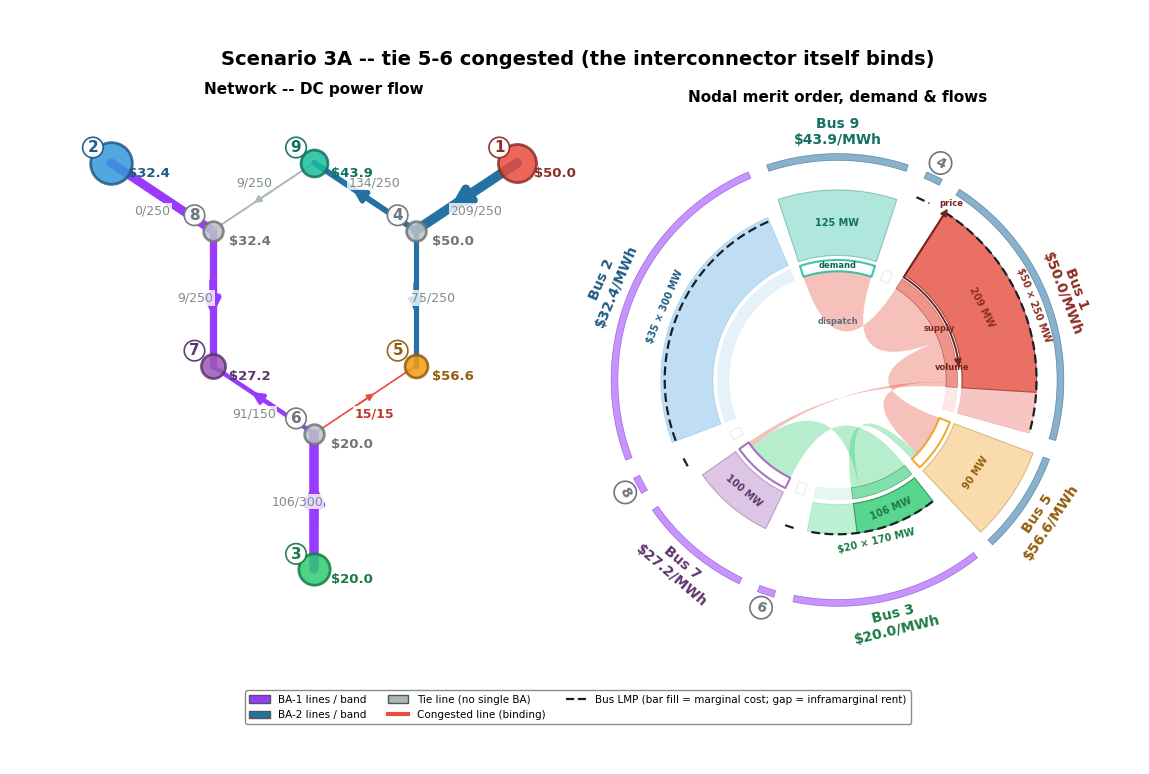

Scenario 3A: rent collected on the tie, R = $732/h. The binding constraint IS the interconnector, so the whole rent is the cross-seam separation and there is only one sensible split -- the tie's rent 50/50 between the BAs at its two ends.

Method 1 -- the tie's rent split 50/50 (Method 2's net-payer rebate is reserved for the internal-constraint case, Scenario 3B, where it does not double-count the seam rent):

,BA-1,BA-2,TOTAL
Generator revenue (lmp*g),2118.3,10454.3,12572.6
Load payment (lmp*d),2722.1,10582.0,13304.1
Net into congestion pool (L - G),603.8,127.7,731.5
Congestion rent allocated (A),365.8,365.8,731.5
Area net position (A - N; 0 => whole),-238.0,238.0,0.0
Load cost net of CRR (L - A),2356.3,10216.3,12572.6


In [15]:
# Scenario 3A -- composite figure + homework-style congestion-revenue table (one method).
net = build_network(SCN_A); pt = compute_ptdf(net, slack_bus='1')
uni = make_engine('UNIFIED', buses=pt.buses); res = solve_engine_dispatch(pt, uni)
example_figure(net, pt, uni, res,
               suptitle='Scenario 3A -- tie 5-6 congested (the interconnector itself binds)')
plt.show()
rtbl1, _, summ = revenue_table(res, pt, LOADS_ALL)
print(f"Scenario 3A: rent collected on the tie, R = ${summ['R']:.0f}/h. The binding constraint "
      f"IS the interconnector, so the whole rent is the cross-seam separation and there is only "
      f"one sensible split -- the tie's rent 50/50 between the BAs at its two ends.")
print("Method 1 -- the tie's rent split 50/50 (Method 2's net-payer rebate is reserved for the "
      "internal-constraint case, Scenario 3B, where it does not double-count the seam rent):")
display(rtbl1)

### Scenario 3B — an *internal* constraint, separation in the *other* BA

Congest a line that
lives entirely inside BA-1 (the exporter). The binding limit both isolates a
price pocket at the BA-1 load behind it **and**, through the shift factors, pulls
**BA-2's prices away from the system price** as generation is redispatched across
the seam. As a result, prices separate on both sides even though the binding line is
internal to BA-1 and no tie is overloaded.

- **Method 1** credits all of the rent to **BA-1** (it physically owns the
  binding line), regardless of where the price separation is felt.
- **Method 2** rebates the cross-seam separation rent $\tau$ to whichever BA is
  the **net payer** into the congestion pool — the side whose load over-paid for
  the separation — funded by the other BA.

Whether the net-payer turns out to be BA-1 or BA-2 depends on the constraint; the
cells below report it from the actual settlement rather than assuming it. Edit
`SCN_B` to choose which internal BA-1 line binds and how hard.

In [16]:
# -- EDIT -- Scenario B: congest a line INTERNAL to BA-1 (the exporter)
SCN_B = {'line_4': 40.0}          # 6-7, internal to BA-1; throttles the cheap bus-3 delivery
# -------------------------------------------------------------------------
net = build_network(SCN_B); pt = compute_ptdf(net, slack_bus='1')
res = solve_engine_dispatch(pt, make_engine('UNIFIED', buses=pt.buses))

print('LMP by bus:', {b: round(res.lmp[b], 1) for b in pt.buses})
print('  BA-1 LMPs:', {b: round(res.lmp[b], 1) for b in BA_DEFS['BA-1']})
print('  BA-2 LMPs:', {b: round(res.lmp[b], 1) for b in BA_DEFS['BA-2']})
print('binding lines:', {l: round(res.line_dual[l], 1) for l in pt.lines if abs(res.line_dual[l]) > 1e-3},
      '(kind:', {l: line_kind(pt, l) for l in pt.lines if abs(res.line_dual[l]) > 1e-3}, ')')

# Line-level diagnostic: where the rent sits, and the seam separation behind Method 2.
_, summ, lr, sep = compare_methods(res, pt, LOADS_ALL)
print('\nper-line congestion rent (binding lines):')
display(lr[lr.rent > 1e-3].round({'rent': 1}))
print('cross-seam separation by tie  (note: a tie carries separation even though it does NOT bind):')
display(sep.round({'sep_rent': 1}))
print(f"total rent R = {summ['R']:.1f}  |  internal BA-2 = {summ['R_int']['BA-2']:.1f}  |  "
      f"internal BA-1 = {summ['R_int']['BA-1']:.1f}  |  on ties = {summ['R_tie']:.1f}")
print(f"cross-seam separation tau = {summ['tau']:.1f}  ->  net-payer (hedged) BA = {summ['hedged_ba']} "
      f"(Method 2 moves tau from {summ['funding_ba']} to {summ['hedged_ba']})")
print('BA-level congestion-revenue accounting (the ledgers) is in the next cell -- Method 1 vs Method 2.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


LMP by bus:

{'1': np.float64(27.7), '2': np.float64(35.0), '3': np.float64(20.0), '4': np.float64(27.7), '5': np.float64(25.0), '6': np.float64(20.0), '7': np.float64(37.1), '8': np.float64(35.0), '9': np.float64(30.2)}

  BA-1 LMPs:

{'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(37.1), '6': np.float64(20.0), '3': np.float64(20.0)}

...

cross-seam separation by tie  (note: a tie carries separation even though it does NOT bind):

,flow,dlam,sep_rent,importing,exporting
line,,,,,
line_2,-98.9,-5.02,496.6,BA-2,BA-1
line_7,116.1,-4.75,551.8,BA-2,BA-1


total rent R = 804.1  |  internal BA-2 = 0.0  |  internal BA-1 = 804.1  |  on ties = 0.0

cross-seam separation tau = 1048.4  ->  net-payer (hedged) BA = BA-2 (Method 2 moves tau from BA-1 to BA-2)

BA-level congestion-revenue accounting (the ledgers) is in the next cell -- Method 1 vs Method 2.

**Reading Scenario 3B.** The binding constraint is inside BA-1, so under
**Method 1** BA-1 banks the entire congestion rent simply because its wires host
the limit. **Method 2** instead rebates the cross-seam separation $\tau$ to the
BA whose participants were the net payers for that separation, so each BA ends up
holding rent commensurate with the price gap *its own meters* bore rather than the
gap its wires happened to host. The `TOTAL` column is identical under both methods
— the rent is only **reallocated**, never created or destroyed. (The contrast is
sharpest when the constraint's home BA and the net-paying BA differ; tune `SCN_B`
to explore that.)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


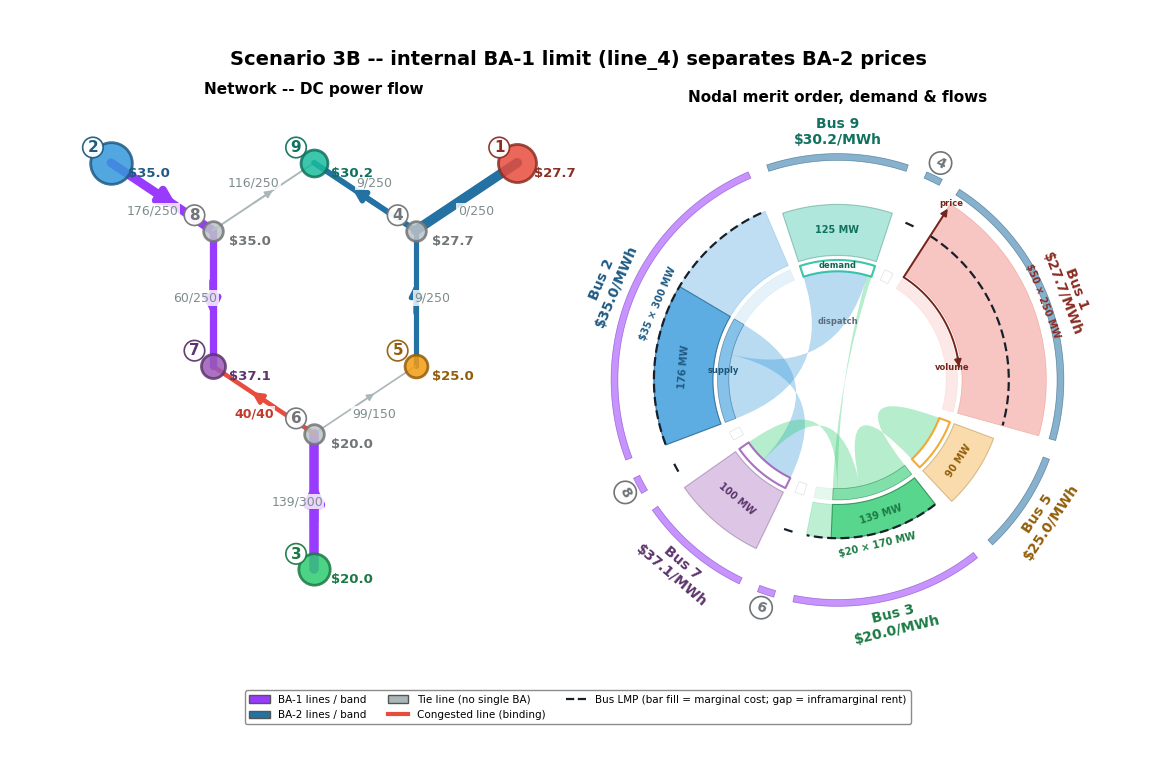

Scenario 3B: rent on the internal BA-1 line, R = $804/h; Method 1 banks it in BA-1 (its wires host the limit), Method 2 moves tau = $1048/h to net-payer BA-2.

Compare the 'Area net position' and 'Load cost net of CRR' rows across the two tables.

Method 1 -- home BA keeps its lines' rent:

,BA-1,BA-2,TOTAL
Generator revenue (lmp*g),8941.0,0.0,8941.0
Load payment (lmp*d),3712.6,6032.5,9745.1
Net into congestion pool (L - G),-5228.4,6032.5,804.1
Congestion rent allocated (A),804.1,0.0,804.1
Area net position (A - N; 0 => whole),6032.5,-6032.5,0.0
Load cost net of CRR (L - A),2908.5,6032.5,8941.0


Method 2 -- rebate cross-seam separation tau to the net-payer BA:

,BA-1,BA-2,TOTAL
Generator revenue (lmp*g),8941.0,0.0,8941.0
Load payment (lmp*d),3712.6,6032.5,9745.1
Net into congestion pool (L - G),-5228.4,6032.5,804.1
Congestion rent allocated (A),-244.3,1048.4,804.1
Area net position (A - N; 0 => whole),4984.1,-4984.1,0.0
Load cost net of CRR (L - A),3956.9,4984.1,8941.0


In [17]:
# Scenario 3B -- composite figure + homework-style congestion-revenue tables.
net = build_network(SCN_B); pt = compute_ptdf(net, slack_bus='1')
uni = make_engine('UNIFIED', buses=pt.buses); res = solve_engine_dispatch(pt, uni)
example_figure(net, pt, uni, res,
               suptitle='Scenario 3B -- internal BA-1 limit (line_4) separates BA-2 prices')
plt.show()
rtbl1, rtbl2, summ = revenue_table(res, pt, LOADS_ALL)
print(f"Scenario 3B: rent on the internal BA-1 line, R = ${summ['R']:.0f}/h; Method 1 banks it "
      f"in BA-1 (its wires host the limit), Method 2 moves tau = ${summ['tau']:.0f}/h to "
      f"net-payer {summ['hedged_ba']}.")
print("Compare the 'Area net position' and 'Load cost net of CRR' rows across the two tables.")
print("Method 1 -- home BA keeps its lines' rent:")
display(rtbl1)
print("Method 2 -- rebate cross-seam separation tau to the net-payer BA:")
display(rtbl2)

### Unified vs independent operation — the two-engine counterfactual

The cross-seam separation exists only because a **single co-optimised clearing**
prices every bus against *all* constraints at once. The counterfactual is
**independent operation**: each BA runs as its own *seams-style engine* on the
same full 9-bus network — serving its own load from its own generators and
enforcing **only its own internal lines**, with everything outside the BA left
unconstrained (a nodal DC-OPF per BA, not a copperplate). No interchange is
scheduled.

Two things surface:

1. On the **base network** each BA clears at its own price — **BA-1 around \$20**
   (it holds the cheap bus-3 and bus-2 units) versus **BA-2 at \$50** (its only
   unit is the dear bus-1 generator). That gap is exactly what trade across the
   seam captures.
2. On the **Scenario-B network**, BA-1's internal `line_4` limit splits prices
   *within* BA-1 (the bus-7 load behind the limit prices up while the bus-3 pocket
   stays at \$20) and, through the shift factors, moves BA-2's prices too. Under
   the **unified clearing** the same constraint is co-optimised against the seam,
   and the resulting cross-seam price separation is the congestion rent that then
   has to be allocated — it exists only because the clearing is coordinated.

In [18]:
# Independent operation: each BA as its OWN seams-style engine on the full network
# -- own gens serve own load, enforcing ONLY its own internal lines (rest relaxed),
# no interchange. A nodal DC-OPF per BA; infeasibility is itself a finding.
def independent_clear(rat):
    n = build_network(rat); pt = compute_ptdf(n, slack_bus='1')
    out = {}
    for ba in BA_DEFS:
        act = [l for l in pt.lines if line_kind(pt, l) == ('internal', ba)]
        try:
            out[ba] = solve_engine_dispatch(pt, make_engine(ba, BA_DEFS[ba], activated=act))
        except RuntimeError:
            out[ba] = None
    return pt, out

# (a) Base network -- both BAs self-serve; the price gap is what motivates trade.
_, base = independent_clear({})
print('independent prices on the BASE network:',
      {ba: (f"${base[ba].energy_price:.0f}" if base[ba] else 'INFEASIBLE') for ba in BA_DEFS})

# (b) Scenario-B network -- the internal BA-2 limit as the counterfactual stress.
ptB, indep = independent_clear(SCN_B)
resU = solve_engine_dispatch(ptB, make_engine('UNIFIED', buses=ptB.buses))
cmp = pd.DataFrame({b: {
    'BA': ba_of(b),
    'independent LMP': (round(indep[ba_of(b)].lmp[b], 1) if indep[ba_of(b)] else float('nan')),
    'unified LMP (Scn B)': round(resU.lmp[b], 1),
} for b in ptB.buses}).T
display(cmp)
for ba in BA_DEFS:
    if indep[ba] is None:
        print(f'{ba} is INFEASIBLE on its own: with the line_4 limit and only its own '
              f'generation it cannot serve its load -- it depends on imports across the '
              f'seam. That dependence is what the unified clearing prices, and what the '
              f'congestion-revenue allocation then divides.')
    else:
        gap = max(indep[ba].lmp[b] for b in BA_DEFS[ba]) - min(indep[ba].lmp[b] for b in BA_DEFS[ba])
        print(f'{ba} independent: clears feasibly, internal price spread ${gap:.1f}/MWh.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


independent prices on the BASE network:

{'BA-1': '$20', 'BA-2': '$50'}

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


,BA,independent LMP,unified LMP (Scn B)
1,BA-2,50.0,27.7
2,BA-1,35.0,35.0
3,BA-1,20.0,20.0
4,BA-2,50.0,27.7
5,BA-2,50.0,25.0
6,BA-1,20.0,20.0
7,BA-1,37.1,37.1
8,BA-1,35.0,35.0
9,BA-2,50.0,30.2


BA-1 independent: clears feasibly, internal price spread $17.1/MWh.

BA-2 independent: clears feasibly, internal price spread $0.0/MWh.

### The two-BA dispatch, per BA (other BA greyed)

The independent two-BA dispatch drawn as a combined network + nodal-merit chart. The other BA's nodes greyed out. Because each BA
clears only its own footprint, its chart shows only its own generation, load, and
within-BA chords. Note BA-2
clearing flat at \$50 across its footprint here (its only unit is the dear bus-1
generator) — the price its consumers pay under independent operation, before the
cheaper imports a coordinated clearing provides.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


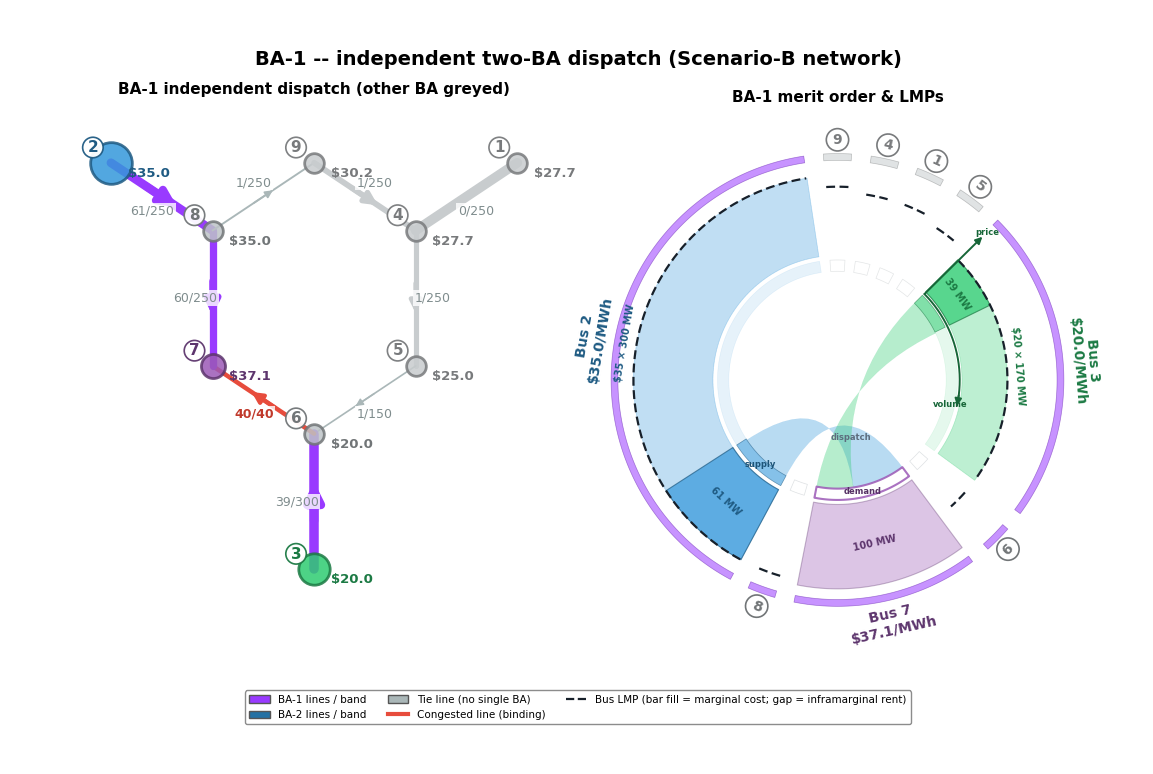

BA-1: energy $28/MWh; own-bus LMPs {'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(37.1), '6': np.float64(20.0), '3': np.float64(20.0)}

BA-1 -- settlement by node (independent clearing):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
2,35.0,60.6,2119.8,0.0,0.0
8,35.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
6,20.0,0.0,0.0,0.0,0.0
3,20.0,39.4,788.7,0.0,0.0
SUBTOTAL,,100.0,2908.5,100.0,3712.6


BA-1 -- marginal value of its internal lines (shadow price x flow):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_3,3,6,39.4,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-60.6,250.0,False,0.0,0.0
TOTAL,,,,,,,804.1


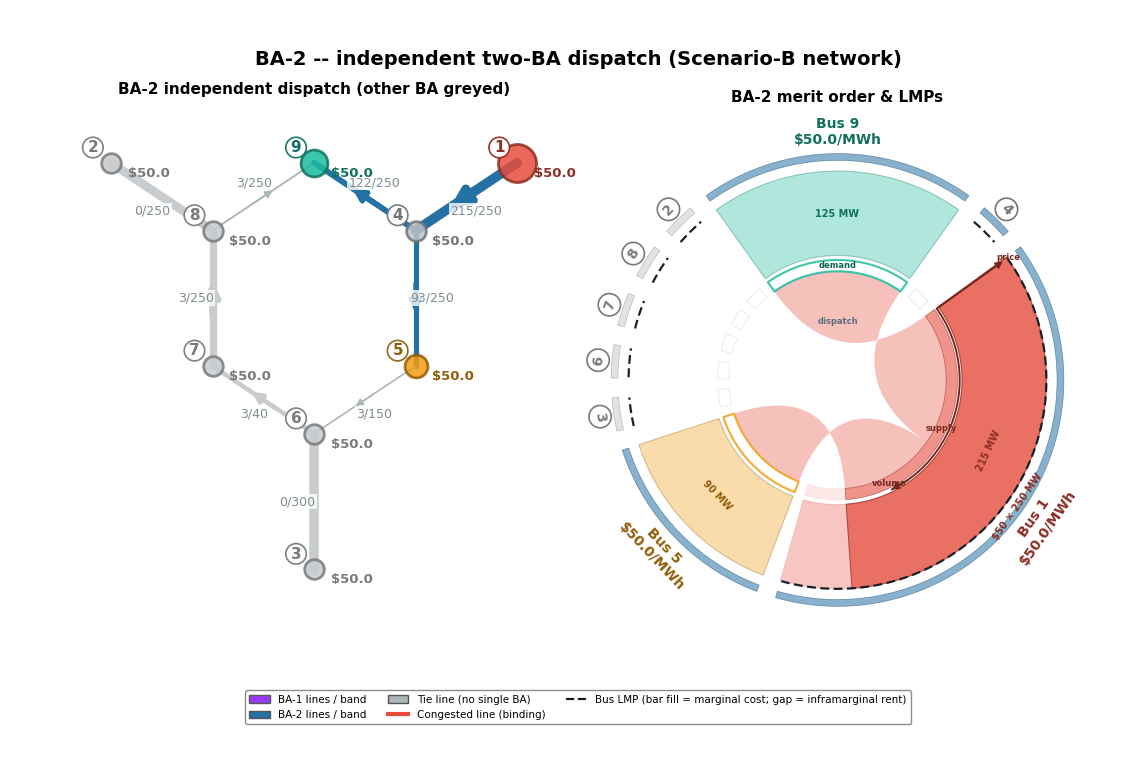

BA-2: energy $50/MWh; own-bus LMPs {'1': np.float64(50.0), '9': np.float64(50.0), '4': np.float64(50.0), '5': np.float64(50.0)}

BA-2 -- settlement by node (independent clearing):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,50.0,215.0,10750.0,0.0,0.0
9,50.0,0.0,0.0,125.0,6250.0
4,50.0,0.0,0.0,0.0,0.0
5,50.0,0.0,0.0,90.0,4500.0
SUBTOTAL,,215.0,10750.0,215.0,10750.0


BA-2 -- marginal value of its internal lines (shadow price x flow):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,215.0,250.0,False,0.0,0.0
line_1,4,5,93.4,250.0,False,0.0,0.0
line_8,9,4,-121.6,250.0,False,0.0,0.0
TOTAL,,,,,,,0.0


In [19]:
# Per-BA composite of the INDEPENDENT two-BA dispatch (Scenario-B network),
# with the other BA's nodes greyed out. Each BA clears only its own footprint,
# so its chart carries only its own generation, load, and within-BA chords.
netB = build_network(SCN_B); ptB = compute_ptdf(netB, slack_bus='1')
for ba in BA_DEFS:
    act = [l for l in ptB.lines if line_kind(ptB, l) == ('internal', ba)]
    eng = make_engine(ba, BA_DEFS[ba], activated=act)
    r = solve_engine_dispatch(ptB, eng)
    other = [b for b in ptB.buses if ba_of(b) != ba]
    example_figure(netB, ptB, eng, r, dim_buses=other,
                   title_left=f'{ba} independent dispatch (other BA greyed)',
                   title_right=f'{ba} merit order & LMPs',
                   suptitle=f'{ba} -- independent two-BA dispatch (Scenario-B network)')
    plt.show()
    print(f"{ba}: energy ${r.energy_price:.0f}/MWh; own-bus LMPs "
          f"{ {b: round(r.lmp[b], 1) for b in BA_DEFS[ba]} }")
    # Bus-level and constraint-level accounting for this BA's independent clearing
    # (the same tables as the unified clearing in Section 2, restricted to the BA).
    print(f'{ba} -- settlement by node (independent clearing):')
    display(settlement_by_bus(r, BA_DEFS[ba], LOADS_ALL))
    print(f'{ba} -- marginal value of its internal lines (shadow price x flow):')
    display(capacity_value_by_line(r, ptB, act))

### Autarky vs unified -- the gains from trade and who captures them

Each BA's **consumer** and **generator** position under
**autarky** (independent operation -- each BA serves its own load on its own internal
limits) versus the **unified** clearing, with the congestion rent rebated to consumers
as congestion-revenue rights (CRR). 

Conventions: consumer payments are negative (cash out), generator revenue positive (cash
in); a BA's generator **position** is producer surplus (revenue minus production cost),
and its **final** consumer position is the load bill net of the CRR rebate. **Autarky also
rebates each BA's own internal congestion rent to its own consumers** -- the same CRR
treatment as the unified case -- so the comparison is like-for-like and the change versus
autarky isolates the gains from trade plus any cross-seam reallocation, which drives the
Pareto check.

*Note on this fleet:* with one unit per bus each generator sets its own bus price, so
producer surplus is ~0 everywhere and the entire price wedge is congestion rent -- all
the distributional action sits on the consumer / CRR side. That degeneracy lifts once the
fleet becomes a real supply mix (a baseload block plus a sloped mid-merit/peaking ramp),
at which point the generator columns carry genuine inframarginal rent and the same ledger
keeps working unchanged.

In [20]:
# Autarky (independent) vs unified, homework-style -- one table per allocation method.
netB = build_network(SCN_B); ptB = compute_ptdf(netB, slack_bus='1')
resU = solve_engine_dispatch(ptB, make_engine('UNIFIED', buses=ptB.buses))
_, indepB = independent_clear(SCN_B)        # each BA on its own internal limits
alloc, summ, _, _ = allocate_congestion_rent(resU, ptB, LOADS_ALL)
COST = {s['bus']: s['cost'] for s in GEN_FLEET.values()}   # bus -> marginal cost

def _agg(result, ba):
    """(load payment, generator revenue, production cost) for a BA at `result` prices."""
    bs = BA_DEFS[ba]
    L  = sum(result.lmp[b] * LOADS_ALL.get(b, 0.0) for b in bs)
    R  = sum(result.lmp[b] * result.gen_by_bus.get(b, 0.0) for b in bs)
    PC = sum(COST.get(b, 0.0) * result.gen_by_bus.get(b, 0.0) for b in bs)
    return L, R, PC

ROWS = ['Autarky: payment / revenue', 'Autarky: production cost',
        'Autarky: own congestion rent (CRR)', 'Autarky: position',
        'Unified: payment / revenue', 'Unified: production cost',
        'Congestion rent (CRR)', 'Final position', 'Delta vs autarky',
        'Pareto (Delta >= 0)']

def autarky_vs_unified(method):
    col = 'method1' if method == 1 else 'method2'
    data = {}
    for ba in BA_DEFS:
        La, Ra, PCa = _agg(indepB[ba], ba)          # autarky (independent)
        Lu, Ru, PCu = _agg(resU, ba)                # unified
        A = alloc.loc[ba, col]                       # unified congestion rent allocated (CRR)
        Ra_int = La - Ra                             # autarky: BA's OWN internal congestion rent
        PSa, PSu = Ra - PCa, Ru - PCu                # producer surplus
        cons_aut = -La + Ra_int                      # autarky consumer position (net of own CRR)
        cons_fin = -Lu + A                           # unified consumer final (net of CRR)
        cons_d = cons_fin - cons_aut                 # consumer change vs autarky
        gen_d  = PSu - PSa                           # generator (surplus) change vs autarky
        data[(ba, 'Consumer')] = {
            'Autarky: payment / revenue': -La, 'Autarky: production cost': '',
            'Autarky: own congestion rent (CRR)': Ra_int, 'Autarky: position': cons_aut,
            'Unified: payment / revenue': -Lu, 'Unified: production cost': '',
            'Congestion rent (CRR)': A, 'Final position': cons_fin,
            'Delta vs autarky': cons_d,
            'Pareto (Delta >= 0)': 'yes' if cons_d >= -1e-6 else 'no'}
        data[(ba, 'Generator')] = {
            'Autarky: payment / revenue': Ra, 'Autarky: production cost': -PCa,
            'Autarky: own congestion rent (CRR)': '', 'Autarky: position': PSa,
            'Unified: payment / revenue': Ru, 'Unified: production cost': -PCu,
            'Congestion rent (CRR)': '', 'Final position': PSu,
            'Delta vs autarky': gen_d,
            'Pareto (Delta >= 0)': 'yes' if gen_d >= -1e-6 else 'no'}
    df = pd.DataFrame(data).reindex(ROWS)
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    return df.map(lambda v: round(v, 1) if isinstance(v, (int, float)) and not isinstance(v, bool) else v)

pc_aut = sum(_agg(indepB[ba], ba)[2] for ba in BA_DEFS)
pc_uni = sum(_agg(resU, ba)[2] for ba in BA_DEFS)
print(f"System production cost: autarky ${pc_aut:,.0f}/h  ->  unified ${pc_uni:,.0f}/h  "
      f"(gains from trade ${pc_aut - pc_uni:,.0f}/h);  congestion rent R = ${summ['R']:.0f}/h.")
print("Autarky rebates each BA's own internal congestion rent to its own consumers, so "
      "Delta-vs-autarky isolates the gains from trade and the cross-seam reallocation.")
print("\nMethod 1 -- home BA keeps its lines' rent (ties split 50/50):")
display(autarky_vs_unified(1))
print("Method 2 -- rebate the cross-seam separation tau to the net-payer BA:")
display(autarky_vs_unified(2))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


System production cost: autarky $13,659/h  ->  unified $8,941/h  (gains from trade $4,717/h);  congestion rent R = $804/h.

Autarky rebates each BA's own internal congestion rent to its own consumers, so Delta-vs-autarky isolates the gains from trade and the cross-seam reallocation.


Method 1 -- home BA keeps its lines' rent (ties split 50/50):

BA-1               BA-2          
                                   Consumer Generator Consumer Generator
Autarky: payment / revenue          -3712.6    2908.5 -10750.0   10750.0
Autarky: production cost                      -2908.5           -10750.0
Autarky: own congestion rent (CRR)    804.1                0.0          
Autarky: position                   -2908.5       0.0 -10750.0       0.0
Unified: payment / revenue          -3712.6    8941.0  -6032.5       0.0
Unified: production cost                      -8941.0               -0.0
Congestion rent (CRR)                 804.1                0.0          
Final position                      -2908.5       0.0  -6032.5       0.0
Delta vs autarky                        0.0       0.0   4717.5       0.0
Pareto (Delta >= 0)                     yes       yes      yes       yes

Method 2 -- rebate the cross-seam separation tau to the net-payer BA:

BA-1               BA-2          
                                   Consumer Generator Consumer Generator
Autarky: payment / revenue          -3712.6    2908.5 -10750.0   10750.0
Autarky: production cost                      -2908.5           -10750.0
Autarky: own congestion rent (CRR)    804.1                0.0          
Autarky: position                   -2908.5       0.0 -10750.0       0.0
Unified: payment / revenue          -3712.6    8941.0  -6032.5       0.0
Unified: production cost                      -8941.0               -0.0
Congestion rent (CRR)                -244.3             1048.4          
Final position                      -3956.9       0.0  -4984.1       0.0
Delta vs autarky                    -1048.4       0.0   5765.9       0.0
Pareto (Delta >= 0)                      no       yes      yes       yes

### Where this goes next

The scaffold above is the **methodology**: a unified nodal clearing, a
congestion-revenue ledger split by BA and tie, and the two allocation rules
(home-keeps-it vs rebate-cross-seam-separation) compared on both a tie-congested
and an internal-constraint case, alongside the unified-vs-separated contrast.

Planned refinements (to work through next):

1. **Two-part supply curves per BA** — a flat baseload block (the in-BA baseload
   unit) plus a smooth linear mid-merit/peaking ramp, replacing the discrete
   three-unit fleet so price separation varies continuously with the squeeze.
2. **Sweep the tie / internal limit** and trace how $\tau$ and each BA's net
   position move — the congestion-revenue analogue of the homework's $C_{tot}$ /
   $R_{tot}$ curves.
3. **Refine the Method-2 transfer rule** (e.g. split $\tau$ between importer load
   and exporter generation rather than a single directed transfer).